In [1]:
%matplotlib widget

## 初期値のコード追加

In [2]:
import math
import random
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

In [3]:
import os
import sys

sys.path.append('/home/morita/src/3D_Estimation/src')

from plot import *
from calculate import *
from optimization import *
from optimization_prior import *

In [4]:
# 線源
source_1 = [3.5, 3.5, 0.0,100]
source_2 = [7.0,3.0,10.0,200]
source_3 = [7.0,10,8.0,150]
source_list = []
source_list.append(source_1)
source_list.append(source_2)
source_list.append(source_3)

In [5]:
# 部屋
x = 10
y = 10
z = 10

In [6]:
g = 1
q_max = 200
q_init = 1/q_max
q1 = np.array([q_init] * (x * y)).reshape(x * y, 1)  # 地面 z=0
q2 = np.array([q_init] * (x * y)).reshape(x * y, 1)  # 天井 z=10
q3 = np.array([q_init] * (y * z)).reshape(y * z, 1)  # 側面1 x=0
q4 = np.array([q_init] * (x * z)).reshape(x * z, 1)  # 側面2 y=0
q5 = np.array([q_init] * (y * z)).reshape(y * z, 1)  # 側面3 x=10
q6 = np.array([q_init] * (x * z)).reshape(x * z, 1)  # 側面4 y=10

In [7]:
vmin = 0
vmax = 1 / q_max

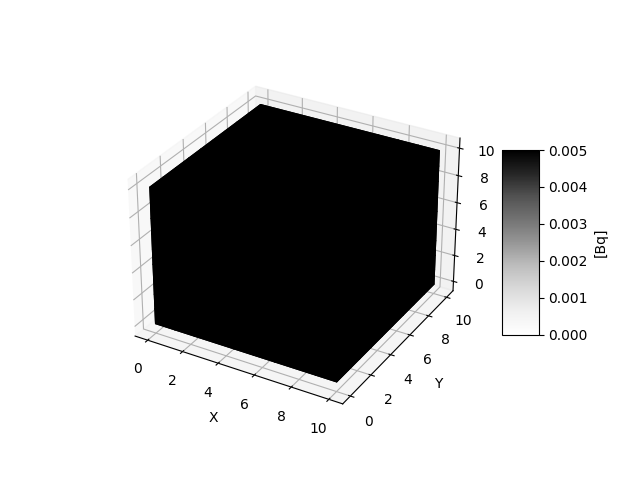

In [8]:
# 3Dヒートマップのプロット
qs = [q1, q2, q3, q4, q5, q6]
plot_3d_heatmap_cube(qs, x, y, z, sources=source_list, vmin=vmin, vmax=vmax)

In [9]:
r = 0.3
m_p = decide_measurement_points(x,y,r)

In [10]:
plot_measurement_points(m_p, source_list, "measurement points", x, y)

ValueError: s must be a scalar, or float array-like with the same size as x and y

In [15]:
# 角度の8通りのシールド向きリスト
shield_orientations = [
    {'theta': (0, np.pi / 2), 'phi': (0, np.pi / 2)},
    {'theta': (0, np.pi / 2), 'phi': (np.pi / 2, np.pi)},
    {'theta': (0, np.pi / 2), 'phi': (np.pi, 3 * np.pi / 2)},
    {'theta': (0, np.pi / 2), 'phi': (3 * np.pi / 2, 2 * np.pi)},
    {'theta': (np.pi / 2, np.pi), 'phi': (0, np.pi / 2)},
    {'theta': (np.pi / 2, np.pi), 'phi': (np.pi / 2, np.pi)},
    {'theta': (np.pi / 2, np.pi), 'phi': (np.pi, 3 * np.pi / 2)},
    {'theta': (np.pi / 2, np.pi), 'phi': (3 * np.pi / 2, 2 * np.pi)}
]

In [16]:
b_m = measurement_shield(m_p, source_list, shield_orientations)
print(len(b_m))
print(b_m)

240
[44.78338344073389, 47.774785801713584, 47.774785801713584, 47.774785801713584, 47.774785801713584, 7.853588008175368, 47.774785801713584, 47.774785801713584, 9.813258256873361, 11.568750667989864, 11.568750667989864, 9.711950770615992, 11.568750667989864, 11.568750667989864, 4.789679344558844, 11.568750667989864, 5.682760626835341, 7.5871287194599555, 7.5871287194599555, 6.233867777306118, 7.5871287194599555, 7.5871287194599555, 4.029794262610015, 4.029794262610015, 7.348881779261526, 5.6379733023956025, 5.529687955758519, 7.348881779261526, 7.348881779261526, 7.348881779261526, 4.278020410527817, 7.348881779261526, 6.2577850591087145, 4.971541216118819, 4.400985161734843, 6.2577850591087145, 6.2577850591087145, 3.779917609854617, 3.779917609854617, 6.2577850591087145, 402.0843136216932, 403.3008738253338, 403.3008738253338, 401.5525001993394, 44.01009368348983, 403.3008738253338, 403.3008738253338, 403.3008738253338, 6.014905115658404, 3.0235027546787103, 6.014905115658404, 6.014

In [44]:
# 例: グリッド生成時に g の値を指定（省略可）
ground_grid = create_grid('z', 0, g=1)    # 地面 z=0
ceiling_grid = create_grid('z', 10, g=1)  # 天井 z=10
side1_grid = create_grid('x', 0, g=1)     # 側面1 x=0
side2_grid = create_grid('y', 0, g=1)     # 側面2 y=0
side3_grid = create_grid('x', 10, g=1)    # 側面3 x=10
side4_grid = create_grid('y', 10, g=1)    # 側面4 y=10


# 結果をリストとして保存
all_grids = {
    "ground": ground_grid,
    "ceiling": ceiling_grid,
    "side1": side1_grid,
    "side2": side2_grid,
    "side3": side3_grid,
    "side4": side4_grid
}


In [18]:
# 各面のA行列の作成
A1 = create_A(10, 10, m_p, ground_grid, shield_orientations)  # 地面 z=0
A2 = create_A(10, 10, m_p, ceiling_grid, shield_orientations) # 天井 z=10
A3 = create_A(10, 10, m_p, side1_grid, shield_orientations)   # 側面1 x=0
A4= create_A(10, 10, m_p, side2_grid, shield_orientations)   # 側面2 y=0
A5= create_A(10, 10, m_p, side3_grid, shield_orientations)   # 側面3 x=10
A6 = create_A(10, 10, m_p, side4_grid, shield_orientations)   # 側面4 y=10

In [19]:
# 全体のA行列を結合
A = np.hstack((A1, A2, A3, A4, A5, A6))

print("Final A matrix:")
print(f"A: {A.shape}")

Final A matrix:
A: (240, 600)


In [20]:
q = np.vstack((q1, q2, q3, q4, q5, q6))
print(f"q: {q.shape}")
b = np.dot(A,q)
print(len(b))

q: (600, 1)
240


In [21]:
b_m_s = np.array(b_m)

In [22]:
init_score = score_func(A,b_m_s,q)
print(f'initial score{init_score}')

initial score-3127597.5287670656


In [22]:
q_optimized = Adam(A, b_m_s, q, learning_rate=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8, max_iter=100000)

In [38]:
q_shapes = [
    (x * y, 1),  # 地面 z=0 に対応
    (x * y, 1),  # 天井 z=10 に対応
    (y * z, 1),  # 側面1 x=0 に対応
    (x * z, 1),  # 側面2 y=0 に対応
    (y * z, 1),  # 側面3 x=10 に対応
    (x * z, 1)   # 側面4 y=10 に対応
]
restored_qs = restore_q(q_optimized, q_shapes)

NameError: name 'q_optimized' is not defined

In [25]:
# 各qの最大値と最小値を求める
all_q_values = np.concatenate([q.flatten() for q in restored_qs])
vmin, vmax = all_q_values.min(), all_q_values.max()

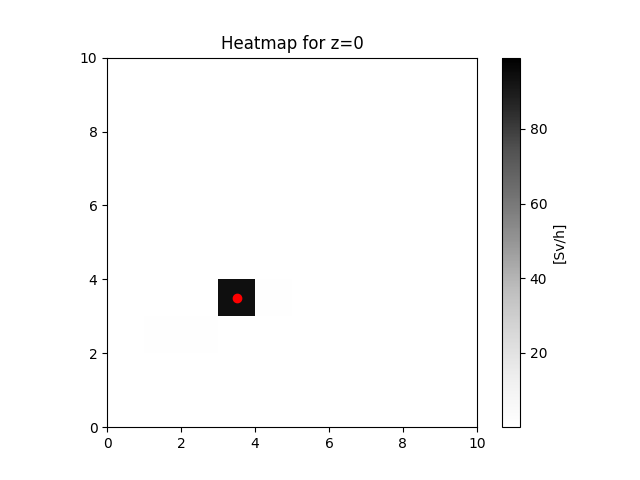

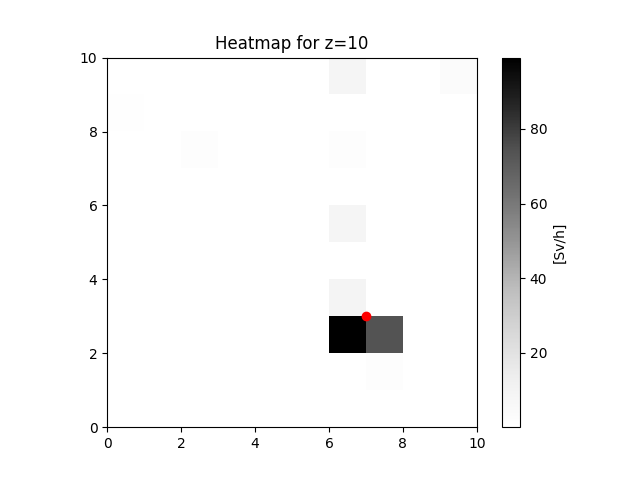

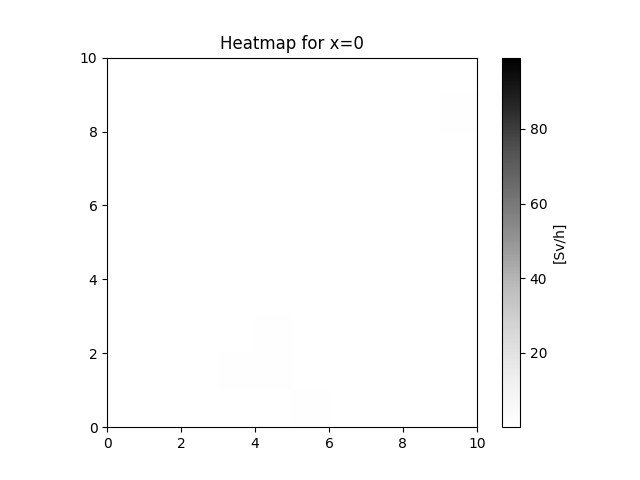

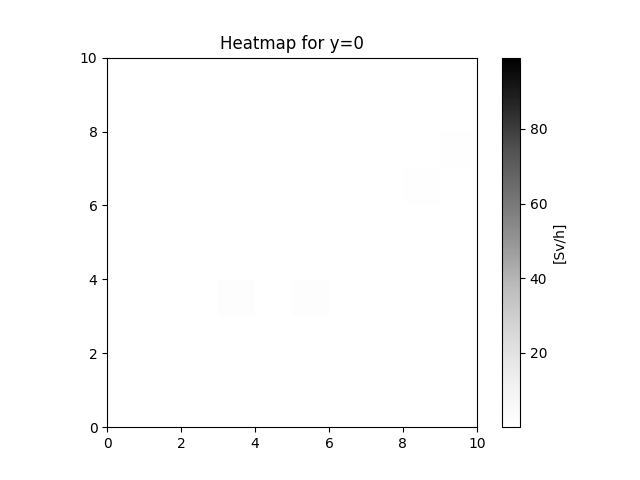

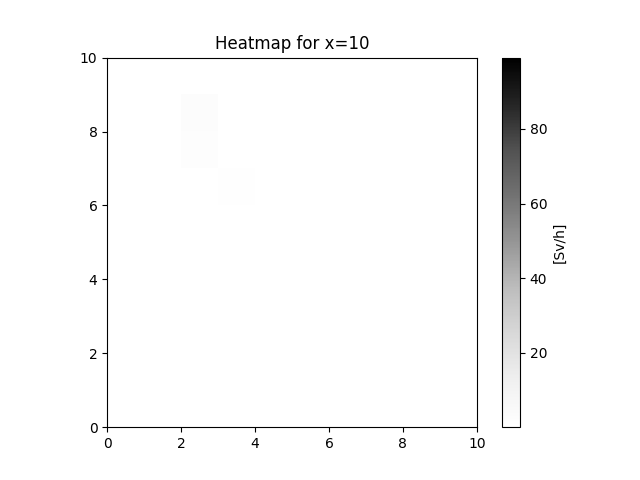

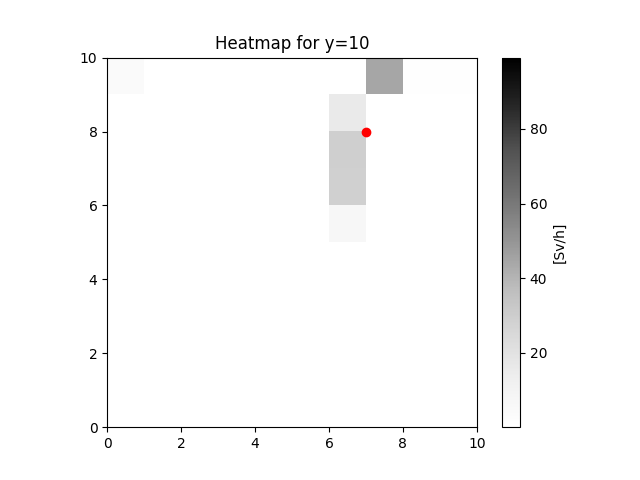

In [26]:
# 地面 z=0
plot_heatmap(restored_qs[0].reshape((x, y)), (x, y), [0, x, 0, y], 'Heatmap for z=0', sources=[(source[0], source[1]) for source in source_list if source[2] == 0], vmin=vmin, vmax=vmax)

# 天井 z=10
plot_heatmap(restored_qs[1].reshape((x, y)), (x, y), [0, x, 0, y], 'Heatmap for z=10', sources=[(source[0], source[1]) for source in source_list if source[2] == 10], vmin=vmin, vmax=vmax)

# 側面1 x=0
plot_heatmap(restored_qs[2].reshape((y, z)), (y, z), [0, y, 0, z], 'Heatmap for x=0', sources=[(source[1], source[2]) for source in source_list if source[0] == 0], vmin=vmin, vmax=vmax)

# 側面2 y=0
plot_heatmap(restored_qs[3].reshape((x, z)), (x, z), [0, x, 0, z], 'Heatmap for y=0', sources=[(source[0], source[2]) for source in source_list if source[1] == 0], vmin=vmin, vmax=vmax)

# 側面3 x=10
plot_heatmap(restored_qs[4].reshape((y, z)), (y, z), [0, y, 0, z], 'Heatmap for x=10', sources=[(source[1], source[2]) for source in source_list if source[0] == 10], vmin=vmin, vmax=vmax)

# 側面4 y=10
plot_heatmap(restored_qs[5].reshape((x, z)), (x, z), [0, x, 0, z], 'Heatmap for y=10', sources=[(source[0], source[2]) for source in source_list if source[1] == 10], vmin=vmin, vmax=vmax)

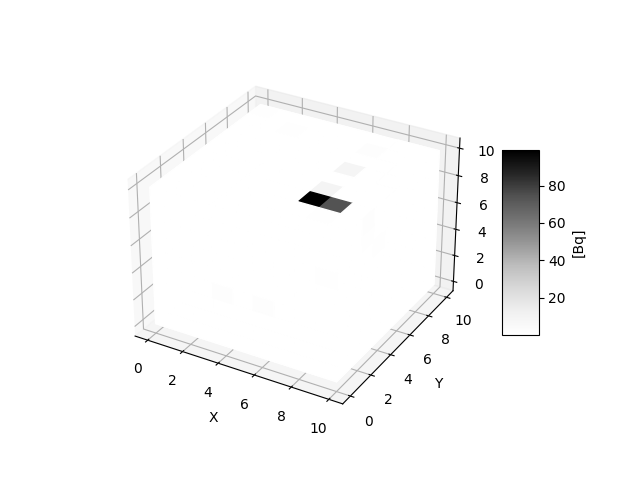

In [27]:
# 各面のデータと最小・最大の放射線量を設定
qs = restored_qs

plot_3d_heatmap_cube(qs, x, y, z, sources=source_list, vmin=vmin, vmax=vmax)

## 以下初期値変更

In [23]:
g = 1
q_max = 200
q_init = 1/q_max
q1 = np.array([q_init] * (x * y)).reshape(x * y, 1)  # 地面 z=0
q2 = np.array([q_init] * (x * y)).reshape(x * y, 1)  # 天井 z=10
q3 = np.array([q_init] * (y * z)).reshape(y * z, 1)  # 側面1 x=0
q4 = np.array([q_init] * (x * z)).reshape(x * z, 1)  # 側面2 y=0
q5 = np.array([q_init] * (y * z)).reshape(y * z, 1)  # 側面3 x=10
q6 = np.array([q_init] * (x * z)).reshape(x * z, 1)  # 側面4 y=10

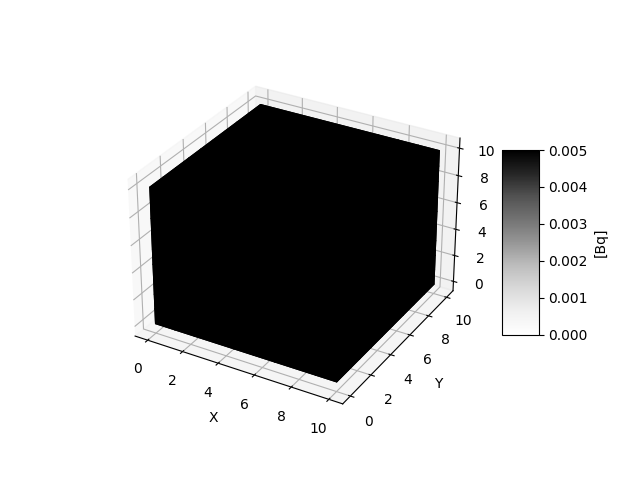

In [24]:
# 3Dヒートマップのプロット
qs = [q1, q2, q3, q4, q5, q6]
plot_3d_heatmap_cube(qs, x, y, z, sources=source_list, vmin=0, vmax=1/q_max)

In [25]:
# 角度の8通りのシールド向きリスト
shield_orientations = [
    {'theta': (0, np.pi / 2), 'phi': (0, np.pi / 2)},
    {'theta': (0, np.pi / 2), 'phi': (np.pi / 2, np.pi)},
    {'theta': (0, np.pi / 2), 'phi': (np.pi, 3 * np.pi / 2)},
    {'theta': (0, np.pi / 2), 'phi': (3 * np.pi / 2, 2 * np.pi)},
    {'theta': (np.pi / 2, np.pi), 'phi': (0, np.pi / 2)},
    {'theta': (np.pi / 2, np.pi), 'phi': (np.pi / 2, np.pi)},
    {'theta': (np.pi / 2, np.pi), 'phi': (np.pi, 3 * np.pi / 2)},
    {'theta': (np.pi / 2, np.pi), 'phi': (3 * np.pi / 2, 2 * np.pi)}
]

In [26]:
rad_all_measurements = measurement_shield(m_p, source_list, shield_orientations)
print(len(rad_all_measurements))
print(rad_all_measurements)

240
[44.78338344073389, 47.774785801713584, 47.774785801713584, 47.774785801713584, 47.774785801713584, 7.853588008175368, 47.774785801713584, 47.774785801713584, 9.813258256873361, 11.568750667989864, 11.568750667989864, 9.711950770615992, 11.568750667989864, 11.568750667989864, 4.789679344558844, 11.568750667989864, 5.682760626835341, 7.5871287194599555, 7.5871287194599555, 6.233867777306118, 7.5871287194599555, 7.5871287194599555, 4.029794262610015, 4.029794262610015, 7.348881779261526, 5.6379733023956025, 5.529687955758519, 7.348881779261526, 7.348881779261526, 7.348881779261526, 4.278020410527817, 7.348881779261526, 6.2577850591087145, 4.971541216118819, 4.400985161734843, 6.2577850591087145, 6.2577850591087145, 3.779917609854617, 3.779917609854617, 6.2577850591087145, 402.0843136216932, 403.3008738253338, 403.3008738253338, 401.5525001993394, 44.01009368348983, 403.3008738253338, 403.3008738253338, 403.3008738253338, 6.014905115658404, 3.0235027546787103, 6.014905115658404, 6.014

In [27]:
def adjust_q_based_on_measurements(m_p, rad_all_measurements, shield_orientations, q_surfaces, x, y, z, min_q_value=1e-6):
    """
    ある計測点での8回回転のうち、同じ計測値が4回以上あった場合、その方向の遮蔽領域のqを低減する。
    
    m_p: 計測点リスト [(x, y, z), ...]
    rad_all_measurements: 各計測点ごとの8方向の計測結果リスト
    shield_orientations: 遮蔽体の8つの向きリスト
    q_surfaces: qのリスト [q1, q2, q3, q4, q5, q6]
    x, y, z: 部屋の寸法
    """
    num_orientations = len(shield_orientations)
    updated_q = [q.copy() for q in q_surfaces]  # qのコピーを作成

    for idx, detector_position in enumerate(m_p):
        measurements = rad_all_measurements[idx * num_orientations:(idx + 1) * num_orientations]
        measurement_counts = {val: measurements.count(val) for val in set(measurements)}

        for measurement, count in measurement_counts.items():#ここよく考えて
            if count >= 4:
                for orientation_idx, orientation in enumerate(shield_orientations):
                    if measurements[orientation_idx] == measurement:
                        for surface_idx, q_surface in enumerate(q_surfaces):
                            for grid_idx in range(len(q_surface)):
                                grid_position = get_grid_position(surface_idx, grid_idx, x, y, z)
                                if shield_blocks_radiation(orientation, grid_position, detector_position):
                                    updated_q[surface_idx][grid_idx] -= q_init/(len(m_p)*2)
                                    updated_q[surface_idx][grid_idx] = max(updated_q[surface_idx][grid_idx], min_q_value)

    return updated_q


In [28]:
# qを計測結果に基づいて更新
updated_q = adjust_q_based_on_measurements(m_p, rad_all_measurements, shield_orientations, 
                                            [q1, q2, q3, q4, q5, q6], x, y, z)

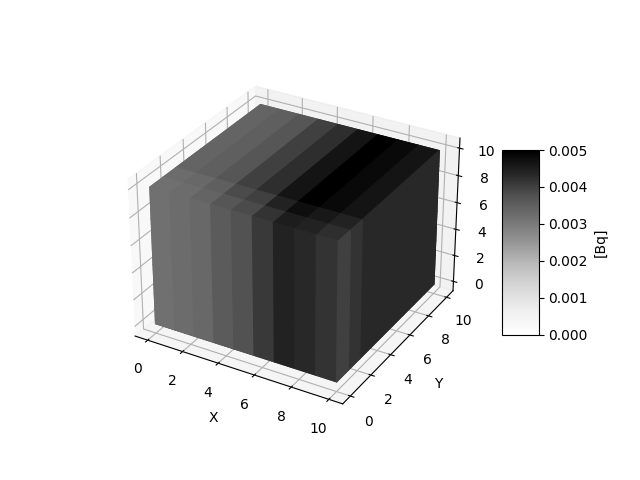

In [29]:
plot_3d_heatmap_cube(updated_q, x, y, z, sources=source_list, vmin=0, vmax=1/q_max)

In [30]:
# 例: グリッド生成時に g の値を指定（省略可）
ground_grid = create_grid('z', 0, g=1)    # 地面 z=0
ceiling_grid = create_grid('z', 10, g=1)  # 天井 z=10
side1_grid = create_grid('x', 0, g=1)     # 側面1 x=0
side2_grid = create_grid('y', 0, g=1)     # 側面2 y=0
side3_grid = create_grid('x', 10, g=1)    # 側面3 x=10
side4_grid = create_grid('y', 10, g=1)    # 側面4 y=10


# 結果をリストとして保存
all_grids = {
    "ground": ground_grid,
    "ceiling": ceiling_grid,
    "side1": side1_grid,
    "side2": side2_grid,
    "side3": side3_grid,
    "side4": side4_grid
}

In [43]:
prior_q_combined = np.vstack(updated_q)
print(prior_q_combined)

q = np.vstack((q1, q2, q3, q4, q5, q6))
print(f"q: {q.shape}")

# b を計算
b = np.dot(A, prior_q_combined)
print(len(b))

[[0.00408333]
 [0.00416667]
 [0.00425   ]
 [0.00425   ]
 [0.00408333]
 [0.00375   ]
 [0.00341667]
 [0.00333333]
 [0.00316667]
 [0.00291667]
 [0.00433333]
 [0.00441667]
 [0.0045    ]
 [0.0045    ]
 [0.00433333]
 [0.00391667]
 [0.00358333]
 [0.00341667]
 [0.00325   ]
 [0.003     ]
 [0.00458333]
 [0.00466667]
 [0.00475   ]
 [0.00475   ]
 [0.0045    ]
 [0.00408333]
 [0.00375   ]
 [0.00358333]
 [0.00341667]
 [0.00308333]
 [0.00466667]
 [0.00475   ]
 [0.00491667]
 [0.005     ]
 [0.00475   ]
 [0.00433333]
 [0.004     ]
 [0.00383333]
 [0.00366667]
 [0.00333333]
 [0.00441667]
 [0.0045    ]
 [0.00466667]
 [0.00475   ]
 [0.00458333]
 [0.00425   ]
 [0.004     ]
 [0.00383333]
 [0.00366667]
 [0.00333333]
 [0.00425   ]
 [0.00433333]
 [0.0045    ]
 [0.00458333]
 [0.00441667]
 [0.00408333]
 [0.00391667]
 [0.00375   ]
 [0.00366667]
 [0.00333333]
 [0.004     ]
 [0.00408333]
 [0.00425   ]
 [0.00433333]
 [0.00416667]
 [0.00391667]
 [0.00383333]
 [0.00366667]
 [0.00358333]
 [0.00333333]
 [0.00375   ]
 [0.00

In [32]:
if np.allclose(prior_q_combined, q):
    print("adjusted_q_combined と q は同じです。")
else:
    print("adjusted_q_combined と q は異なります。")

adjusted_q_combined と q は異なります。


In [33]:
r_a_s = np.array(rad_all_measurements)

In [34]:
init_score = score_func_prior(A,r_a_s,q,prior_q_combined)
print(f'initial score{init_score}')

initial score-3127597.529667218


In [35]:
q_optimized_initial = Adam_prior(A, r_a_s, q, prior_q_combined, learning_rate=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8, max_iter=100000)

Iteration 0, Score: 1217985.1486
Iteration 100, Score: 3728409.6380
Iteration 200, Score: 3558117.3468
Iteration 300, Score: 3495571.8831
Iteration 400, Score: 3465518.1202
Iteration 500, Score: 3446538.0838
Iteration 600, Score: 3428171.0773
Iteration 700, Score: 3413047.6193
Iteration 800, Score: 3399991.8372
Iteration 900, Score: 3389155.1996
Iteration 1000, Score: 3379278.8469
Iteration 1100, Score: 3371420.4668
Iteration 1200, Score: 3364056.1409
Iteration 1300, Score: 3357328.9479
Iteration 1400, Score: 3351435.6921
Iteration 1500, Score: 3346124.9510
Iteration 1600, Score: 3341299.4732
Iteration 1700, Score: 3336909.9942
Iteration 1800, Score: 3333045.8965
Iteration 1900, Score: 3329542.9428
Iteration 2000, Score: 3326341.8499
Iteration 2100, Score: 3323457.8120
Iteration 2200, Score: 3320857.8880
Iteration 2300, Score: 3318470.1788
Iteration 2400, Score: 3316354.6695
Iteration 2500, Score: 3314460.4640
Iteration 2600, Score: 3312692.9983
Iteration 2700, Score: 3311040.9988
Iter

In [36]:
# adjusted_q_combined と q を比較
comparison = adjusted_q_combined == q
if np.all(comparison):
    print("adjusted_q_combined と q は全ての要素で一致しています。")
else:
    # 異なる要素のインデックスを取得
    diff_indices = np.where(~comparison)
    
    # 異なる要素の値を取得
    adjusted_q_diff_values = adjusted_q_combined[diff_indices]
    q_diff_values = q[diff_indices]
    
    # 異なる要素の差分を計算
    differences = adjusted_q_diff_values - q_diff_values
    
    # 出力
    for idx, (adjusted_val, q_val, diff) in enumerate(zip(adjusted_q_diff_values, q_diff_values, differences)):
        print(f"インデックス {diff_indices[0][idx]}: adjusted_q_combined={adjusted_val}, q={q_val}, 差分={diff}")
    
    # 差分の統計情報を表示
    print(f"\n最大差: {np.max(np.abs(differences))}")
    print(f"最小差: {np.min(np.abs(differences))}")
    print(f"平均差: {np.mean(differences)}")
    print(f"差分の標準偏差: {np.std(differences)}")


NameError: name 'adjusted_q_combined' is not defined

In [39]:
q_shapes = [
    (x * y, 1),  # 地面 z=0 に対応
    (x * y, 1),  # 天井 z=10 に対応
    (y * z, 1),  # 側面1 x=0 に対応
    (x * z, 1),  # 側面2 y=0 に対応
    (y * z, 1),  # 側面3 x=10 に対応
    (x * z, 1)   # 側面4 y=10 に対応
]
restored_qs_initial = restore_q(q_optimized_initial, q_shapes)

In [40]:
# 各qの最大値と最小値を求める
all_q_values_initial = np.concatenate([q.flatten() for q in restored_qs_initial])
vmin_ini, vmax_ini = all_q_values_initial.min(), all_q_values_initial.max()

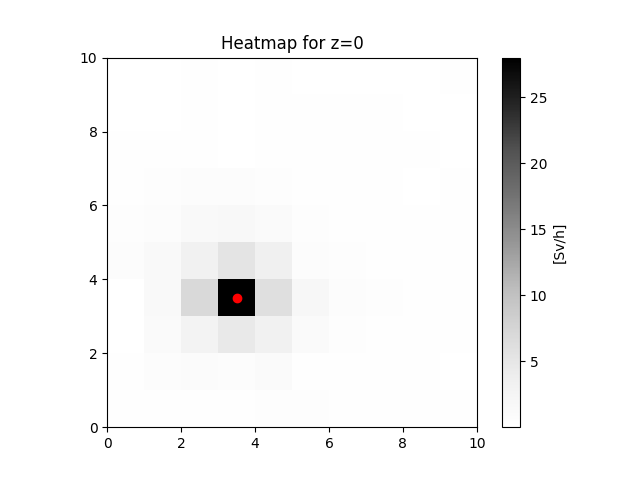

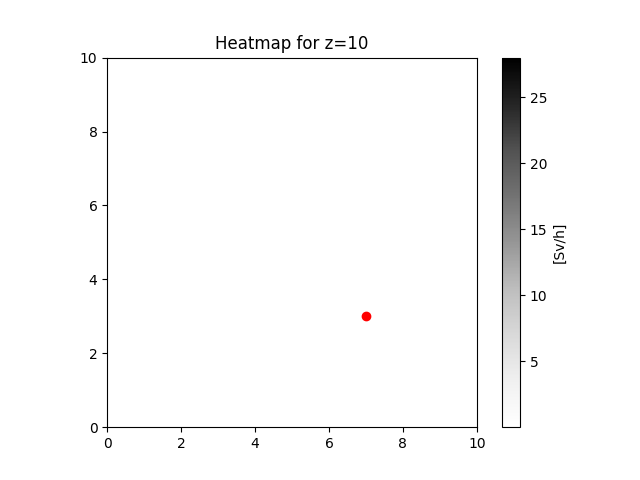

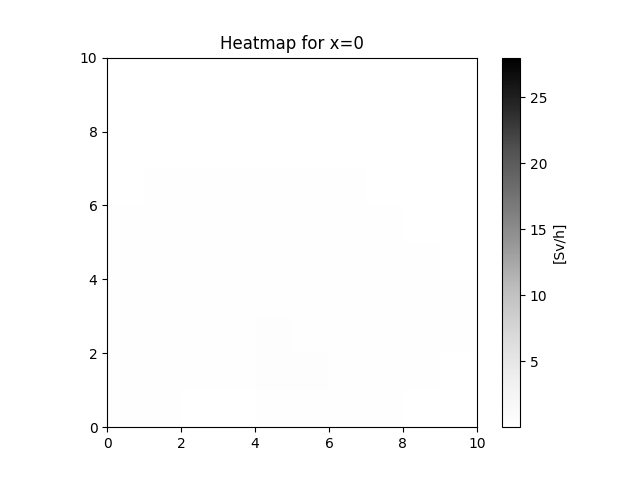

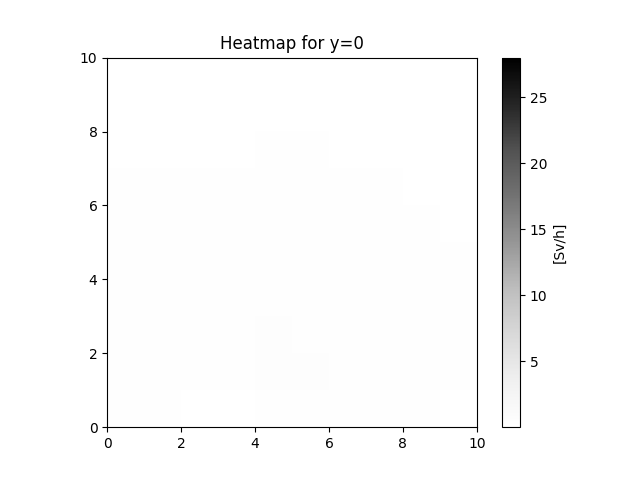

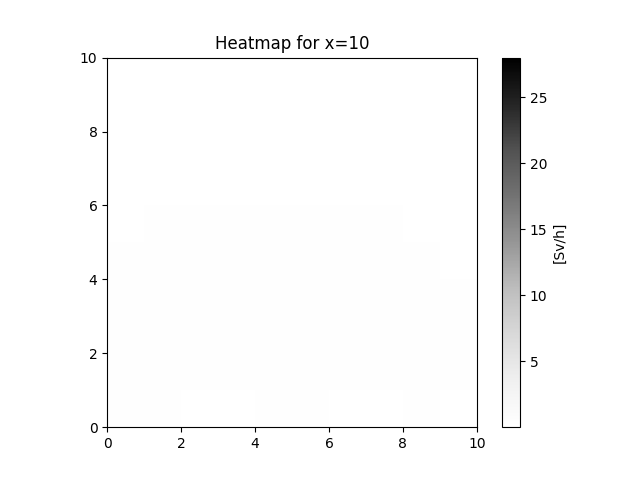

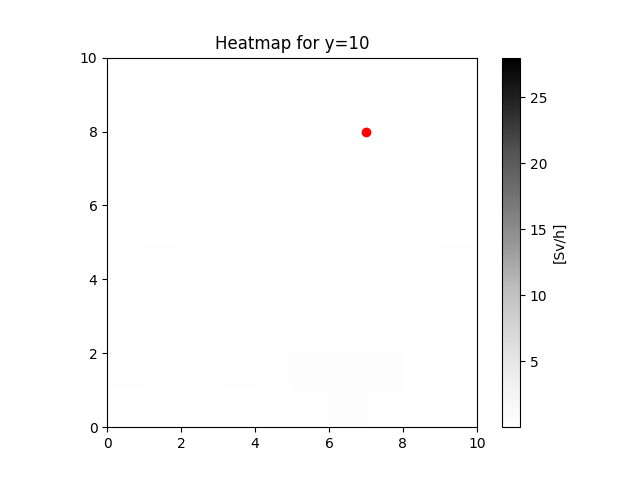

In [41]:
# 地面 z=0
plot_heatmap(restored_qs_initial[0].reshape((x, y)), (x, y), [0, x, 0, y], 'Heatmap for z=0', sources=[(source[0], source[1]) for source in source_list if source[2] == 0], vmin=vmin_ini, vmax=vmax_ini)

# 天井 z=10
plot_heatmap(restored_qs_initial[1].reshape((x, y)), (x, y), [0, x, 0, y], 'Heatmap for z=10', sources=[(source[0], source[1]) for source in source_list if source[2] == 10], vmin=vmin_ini, vmax=vmax_ini)

# 側面1 x=0
plot_heatmap(restored_qs_initial[2].reshape((y, z)), (y, z), [0, y, 0, z], 'Heatmap for x=0', sources=[(source[1], source[2]) for source in source_list if source[0] == 0], vmin=vmin_ini, vmax=vmax_ini)

# 側面2 y=0
plot_heatmap(restored_qs_initial[3].reshape((x, z)), (x, z), [0, x, 0, z], 'Heatmap for y=0', sources=[(source[0], source[2]) for source in source_list if source[1] == 0], vmin=vmin_ini, vmax=vmax_ini)

# 側面3 x=10
plot_heatmap(restored_qs_initial[4].reshape((y, z)), (y, z), [0, y, 0, z], 'Heatmap for x=10', sources=[(source[1], source[2]) for source in source_list if source[0] == 10], vmin=vmin_ini, vmax=vmax_ini)

# 側面4 y=10
plot_heatmap(restored_qs_initial[5].reshape((x, z)), (x, z), [0, x, 0, z], 'Heatmap for y=10', sources=[(source[0], source[2]) for source in source_list if source[1] == 10], vmin=vmin_ini, vmax=vmax_ini)

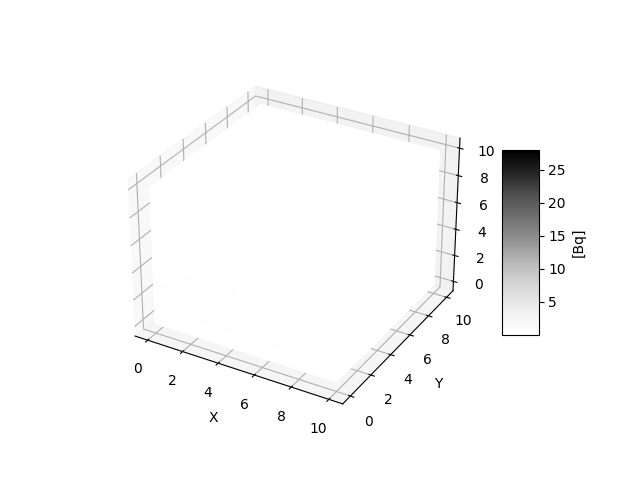

In [47]:
# 各面のデータと最小・最大の放射線量を設定

plot_3d_heatmap_cube(restored_qs_initial, x, y, z, sources=source_list, vmin=vmin_ini, vmax=vmax_ini)